# House Prices — EDA, Preprocessing & Model Selection

This notebook is the **complete experimentation stage** of the House Prices project.

The goal is to finish the data understanding and preprocessing decisions here before extracting the stable logic into `src/`.

**Workflow**

`Raw data → Cleaning → EDA → Transformations → Encoding → Outlier experiment → Train/Validation split → Model comparison → Final decision`

> The Kaggle `test.csv` is intentionally kept untouched during experimentation.

## 1. Load the data

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**What we set up**

We import only the libraries needed in this notebook. `train` will be our main cleaned training DataFrame throughout the EDA. We avoid creating many competing copies of the dataset.

In [2]:
train = pd.read_csv("../data/raw/train.csv")

print("Shape:", train.shape)
train.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**What we learned**

The dataset contains **1,460 houses and 81 columns**. `SalePrice` is the target, while `Id` is an identifier rather than a predictive feature.

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

**What we learned**

The dataset mixes numeric and categorical features, and several categorical columns contain missing values. These missing values must be interpreted using the Ames data description rather than automatically treating every blank as ordinary missing data.

## 2. Missing-value investigation and cleaning

In [4]:
missing = train.isna().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

**What we learned**

Most missingness is concentrated in groups such as `PoolQC`, `MiscFeature`, `Alley`, `FireplaceQu`, the basement columns, and the garage columns. In Ames, many of these blanks mean that the feature **does not exist** (for example, no pool or no alley), so they should be represented as a meaningful category such as `"None"`.

In [5]:
# Check the two important exception patterns before filling structural NaN values.

masvnr_mismatch = train.loc[
    train["MasVnrType"].isna() &
    train["MasVnrArea"].fillna(0).ne(0)
]

bsmt_group = [
    "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2"
]

bsmt_na_count = train[bsmt_group].isna().sum(axis=1)

bsmt_partial = train.loc[
    (bsmt_na_count > 0) & (bsmt_na_count < 5),
    bsmt_group
]

print("MasVnrType missing but MasVnrArea > 0:", len(masvnr_mismatch))
print(masvnr_mismatch[["MasVnrType", "MasVnrArea"]])

print("\nPartial basement missingness:", len(bsmt_partial))
print(bsmt_partial)

MasVnrType missing but MasVnrArea > 0: 5
     MasVnrType  MasVnrArea
624         NaN       288.0
773         NaN         1.0
1230        NaN         1.0
1300        NaN       344.0
1334        NaN       312.0

Partial basement missingness: 2
    BsmtQual BsmtCond BsmtExposure BsmtFinType1 BsmtFinType2
332       Gd       TA           No          GLQ          NaN
948       Gd       TA          NaN          Unf          Unf


**What we learned**

Two important exceptions were found:

- Five rows have a real masonry veneer area but no recorded `MasVnrType`.
- Two rows have a real basement but exactly one basement field is unrecorded.

This means we must **not** blindly convert every blank in these groups to `"None"`.

In [6]:
# Fix the verified exceptions first.

masvnr_mode = train.loc[
    train["MasVnrType"].notna() &
    (train["MasVnrType"] != "None"),
    "MasVnrType"
].mode()[0]

train.loc[masvnr_mismatch.index, "MasVnrType"] = masvnr_mode

for col in bsmt_group:
    fix_idx = train.index[
        train[col].isna() &
        (bsmt_na_count > 0) &
        (bsmt_na_count < 5)
    ]

    if len(fix_idx):
        col_mode = train.loc[
            train[col].notna() &
            (train[col] != "None"),
            col
        ].mode()[0]

        train.loc[fix_idx, col] = col_mode

# Structural categorical missingness: no feature exists.
categorical_none_cols = [
    "Alley", "MasVnrType",
    "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2",
    "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature"
]

train[categorical_none_cols] = train[categorical_none_cols].fillna("None")

# Unknown categorical value.
train["Electrical"] = train["Electrical"].fillna(train["Electrical"].mode()[0])

# Numeric missingness.
train["MasVnrArea"] = train["MasVnrArea"].fillna(0)
train["GarageYrBlt"] = train["GarageYrBlt"].fillna(train["YearBuilt"])

train["LotFrontage"] = (
    train.groupby("Neighborhood")["LotFrontage"]
    .transform(lambda s: s.fillna(s.median()))
)

**What we did and why**

We handled each missing-value pattern according to its meaning:

- Structural absence → `"None"`.
- Unknown `Electrical` → mode.
- No masonry veneer → `MasVnrArea = 0`.
- Missing `GarageYrBlt` → `YearBuilt`, because `0` is not a meaningful year.
- `LotFrontage` → neighborhood median because frontage depends on local lot structure.

These are **data-cleaning decisions**, not feature engineering.

In [7]:
print("Missing values remaining:", train.isna().sum().sum())

Missing values remaining: 0


**What we learned**

The cleaning stage now leaves **zero missing values** in the training data.

In [8]:
import sys
sys.path.append("..")

from src.preprocessing import AmesCleaner

raw = pd.read_csv("../data/raw/train.csv")

cleaner = AmesCleaner()
cleaner.fit(raw)
cleaned = cleaner.transform(raw)

pd.testing.assert_frame_equal(
    cleaned.sort_index(axis=1),
    train.sort_index(axis=1),
    check_dtype=False
)

print("src.AmesCleaner matches the notebook cleaning exactly.")

AssertionError: DataFrame are different

DataFrame shape mismatch
[left]:  (1460, 80)
[right]: (1460, 81)

**Why this check matters**

The notebook remains our experimentation space, while `src.preprocessing.AmesCleaner` is the reusable implementation. The assertion proves that the existing source module currently reproduces the notebook's cleaning logic exactly.

We are **not rewriting the `src` file here**.

## 3. Basic data-quality checks

In [9]:
train = train.drop(columns=["Id"])

print("Shape after dropping Id:", train.shape)
print("Duplicate rows:", train.duplicated().sum())

Shape after dropping Id: (1460, 80)
Duplicate rows: 0


**What we learned**

`Id` is a row identifier, so it is not a predictive feature and is removed. The dataset has **no exact duplicate rows**.

In [10]:
print("BldgType:", sorted(train["BldgType"].unique()))
print("MSZoning:", sorted(train["MSZoning"].unique()))
print("Exterior1st:", sorted(train["Exterior1st"].unique()))
print("Exterior2nd:", sorted(train["Exterior2nd"].unique()))

BldgType: ['1Fam', '2fmCon', 'Duplex', 'Twnhs', 'TwnhsE']
MSZoning: ['C (all)', 'FV', 'RH', 'RL', 'RM']
Exterior1st: ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace', 'CBlock', 'CemntBd', 'HdBoard', 'ImStucc', 'MetalSd', 'Plywood', 'Stone', 'Stucco', 'VinylSd', 'Wd Sdng', 'WdShing']
Exterior2nd: ['AsbShng', 'AsphShn', 'Brk Cmn', 'BrkFace', 'CBlock', 'CmentBd', 'HdBoard', 'ImStucc', 'MetalSd', 'Other', 'Plywood', 'Stone', 'Stucco', 'VinylSd', 'Wd Sdng', 'Wd Shng']


**What we learned**

Some values in the actual CSV use spelling/casing that differs from `data_description.txt`, and `Exterior1st` / `Exterior2nd` use different spellings for some related materials.

We **do not rename the columns or rewrite the raw category values**. We simply document the mismatch and make sure the encoder learns from the actual training values.

In [11]:
print(train["Utilities"].value_counts())

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64


**What we learned**

`Utilities` is extremely imbalanced (`AllPub` dominates and only one row is `NoSeWa`). We **keep the feature for now** rather than dropping it. Keeping it is inexpensive on this small dataset, and later model validation can tell us whether it contributes useful signal.

## 4. Distribution analysis

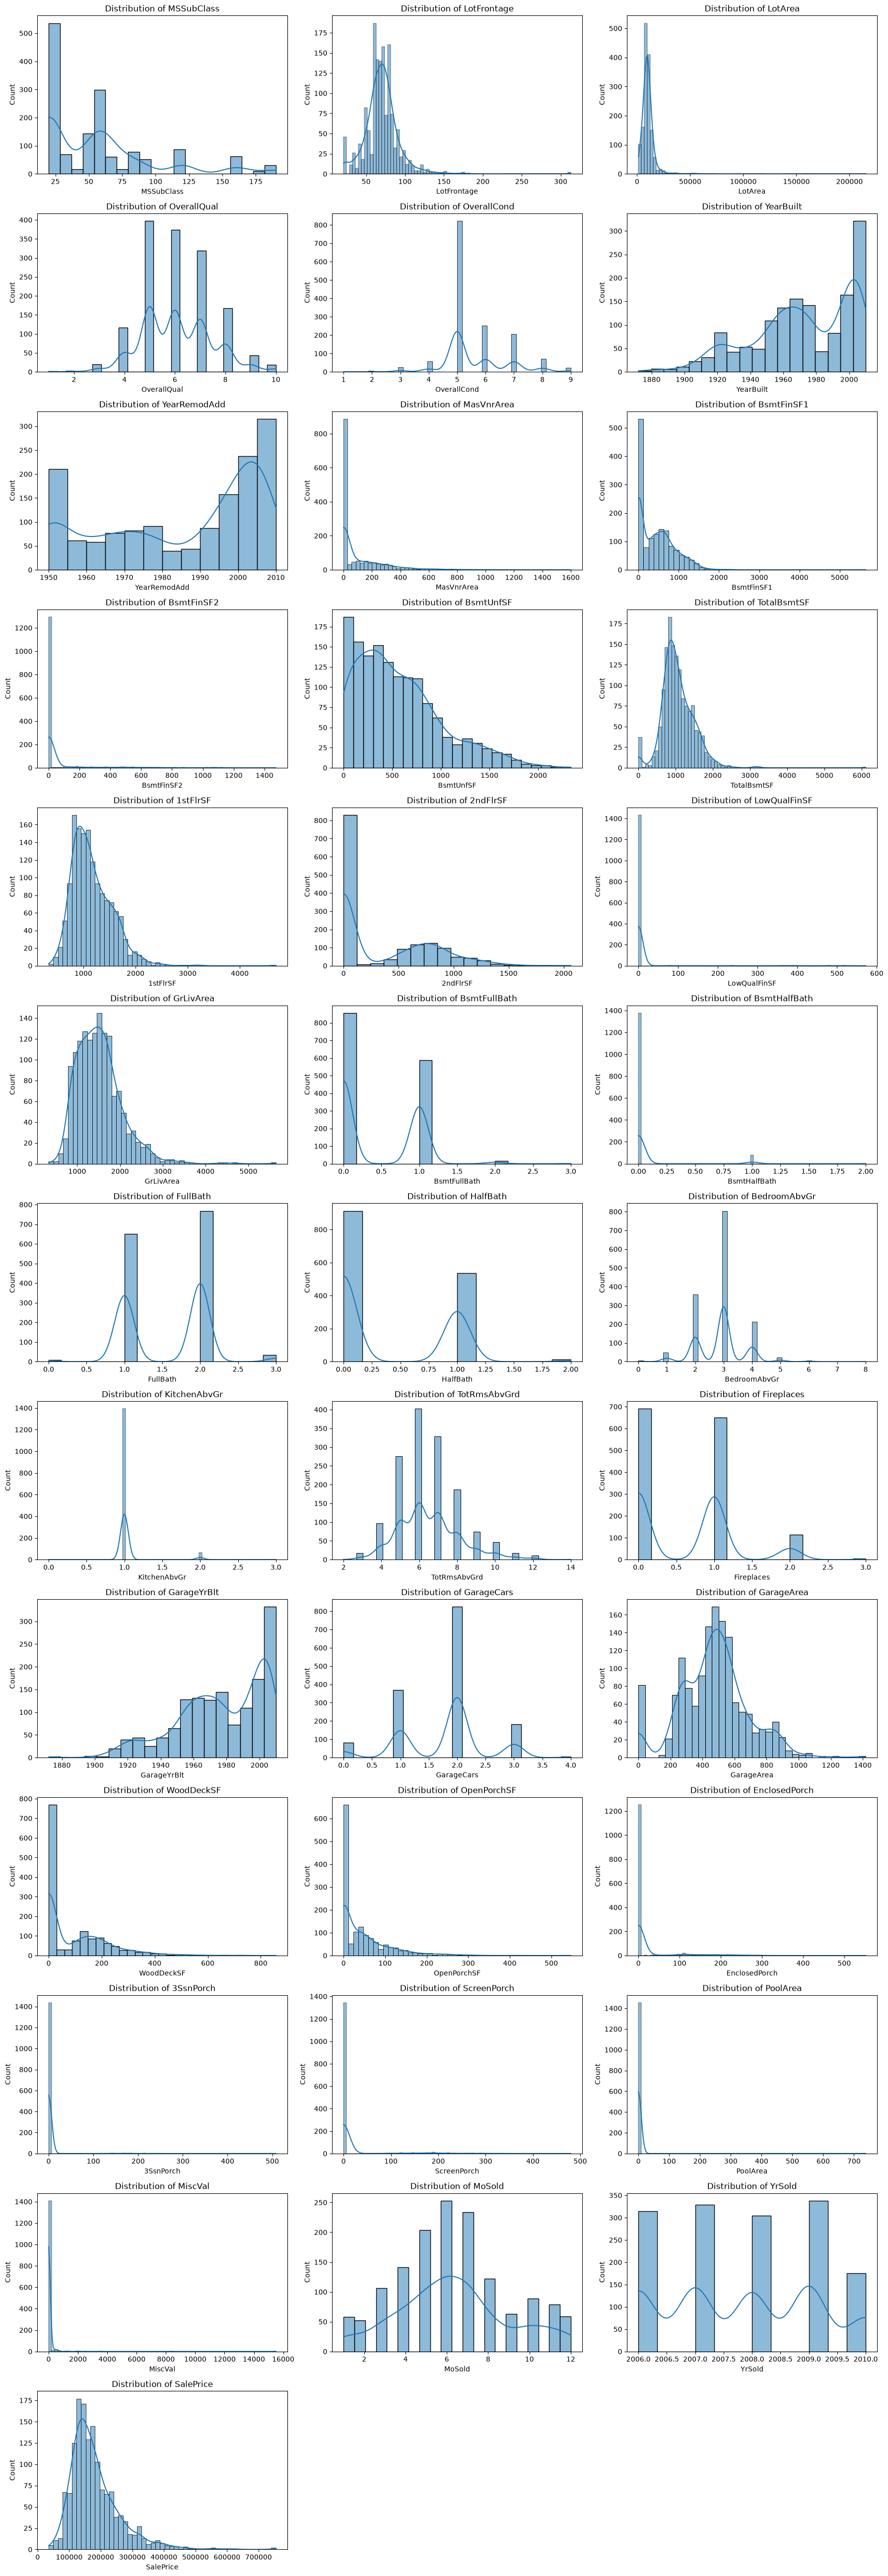

In [12]:
numeric_cols = train.select_dtypes(include="number").columns

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = np.atleast_1d(axes).flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(train[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)

for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

**What we learned**

The broad numeric scan shows that several continuous measurements are strongly right-skewed. These are the main candidates for a log transformation.

Years such as `YearBuilt`, `YearRemodAdd`, and `YrSold` are **calendar/year variables**, not measurements of size or area. We do not log-transform them simply because they are numeric.

## 5. Target variable — SalePrice

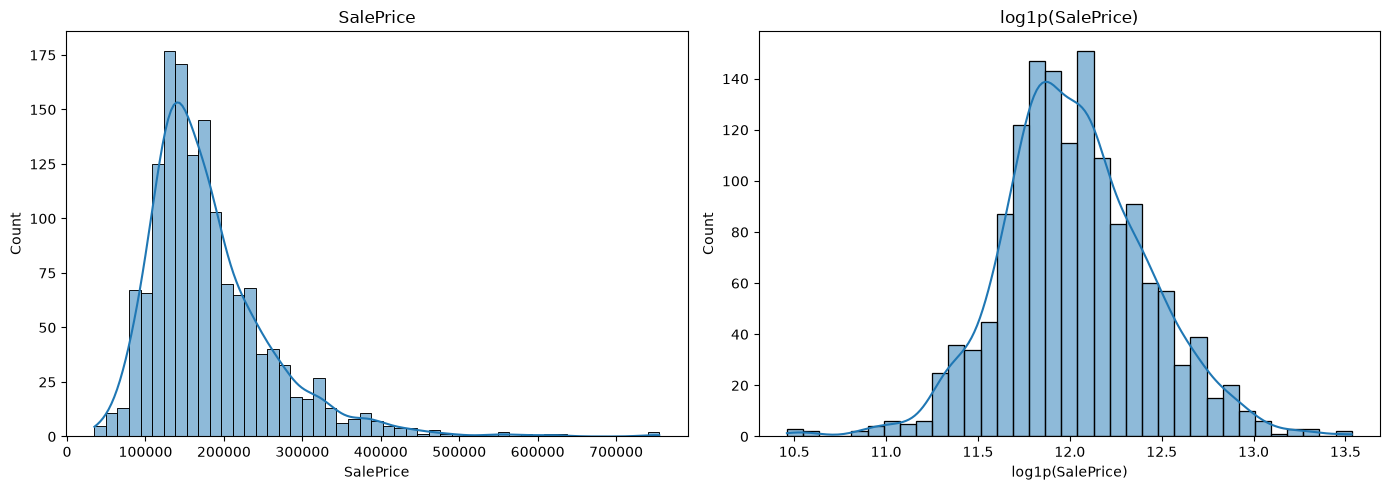

Raw SalePrice skew: 1.883
log1p(SalePrice) skew: 0.121


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice")
axes[0].set_xlabel("SalePrice")

sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("log1p(SalePrice)")
axes[1].set_xlabel("log1p(SalePrice)")

plt.tight_layout()
plt.show()

print("Raw SalePrice skew:", round(train["SalePrice"].skew(), 3))
print("log1p(SalePrice) skew:", round(np.log1p(train["SalePrice"]).skew(), 3))

**What we learned**

`SalePrice` is clearly right-skewed, while `log1p(SalePrice)` is much closer to symmetric. Kaggle's competition metric is based on logarithmic prediction error, so we will train the regression models on `log1p(SalePrice)` and convert predictions back with `expm1()` when we want prices in dollars.

## 6. Important feature relationships

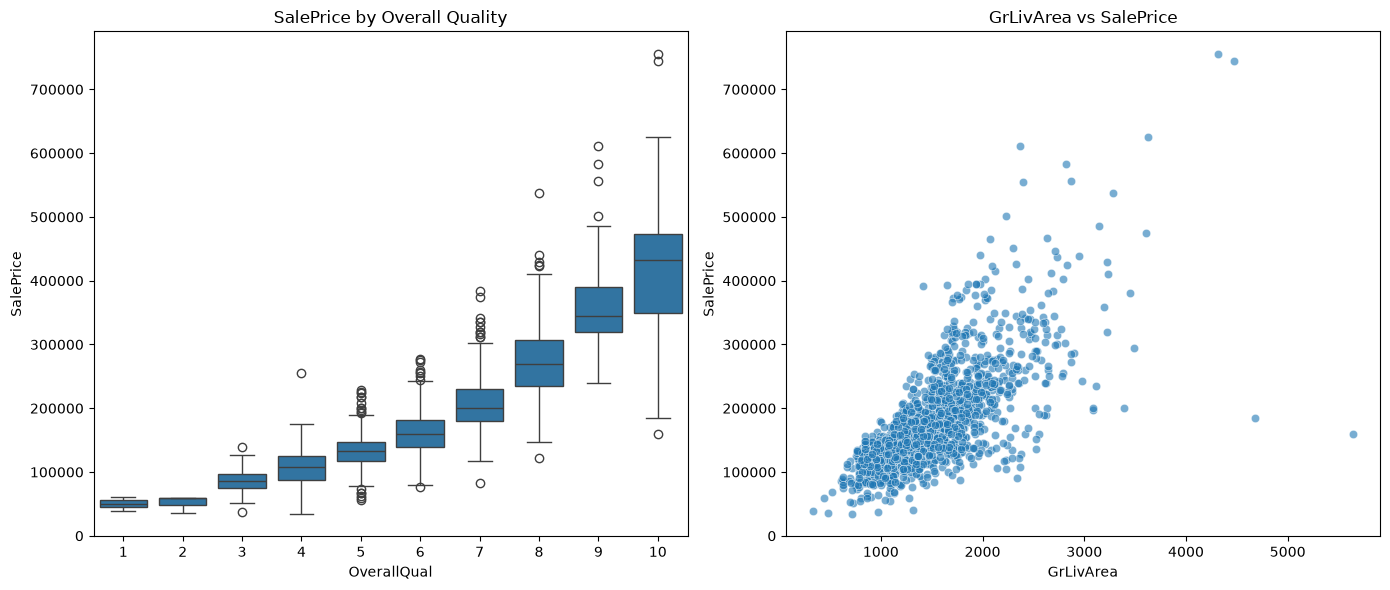

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=train,
    x="OverallQual",
    y="SalePrice",
    ax=axes[0]
)
axes[0].set_title("SalePrice by Overall Quality")

sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice",
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title("GrLivArea vs SalePrice")

plt.tight_layout()
plt.show()

**What we learned**

`OverallQual` has a strong monotonic relationship with price. `GrLivArea` also has a strong positive relationship, but the scatter plot reveals two unusually large living-area observations whose prices do not follow the main trend.

In [15]:
outlier_mask = (
    (train["GrLivArea"] > 4000) &
    (train["SalePrice"] < 300000)
)

outlier_rows = train.loc[outlier_mask, ["GrLivArea", "SalePrice"]]

outlier_rows

,GrLivArea,SalePrice
523,4676,184750
1298,5642,160000


**Outlier decision — not deletion yet**

These are the two observations we identified as potentially misleading. We will **keep them for now**, then later compare model validation performance with and without them using exactly the same validation set.

The validation result—not visual appearance alone—will guide the decision.

## 7. Correlation and multicollinearity

In [16]:
numeric_corr = train.select_dtypes(include="number").corr()["SalePrice"]    .sort_values(ascending=False)

numeric_corr.head(11)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
GarageYrBlt     0.508043
Name: SalePrice, dtype: float64

**What we learned**

`OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, and `TotalBsmtSF` are among the strongest numerical relationships with `SalePrice`.

Some predictors are also strongly related to one another, which is important for linear models. Regularization (Ridge/Lasso/Elastic Net) can help with this.

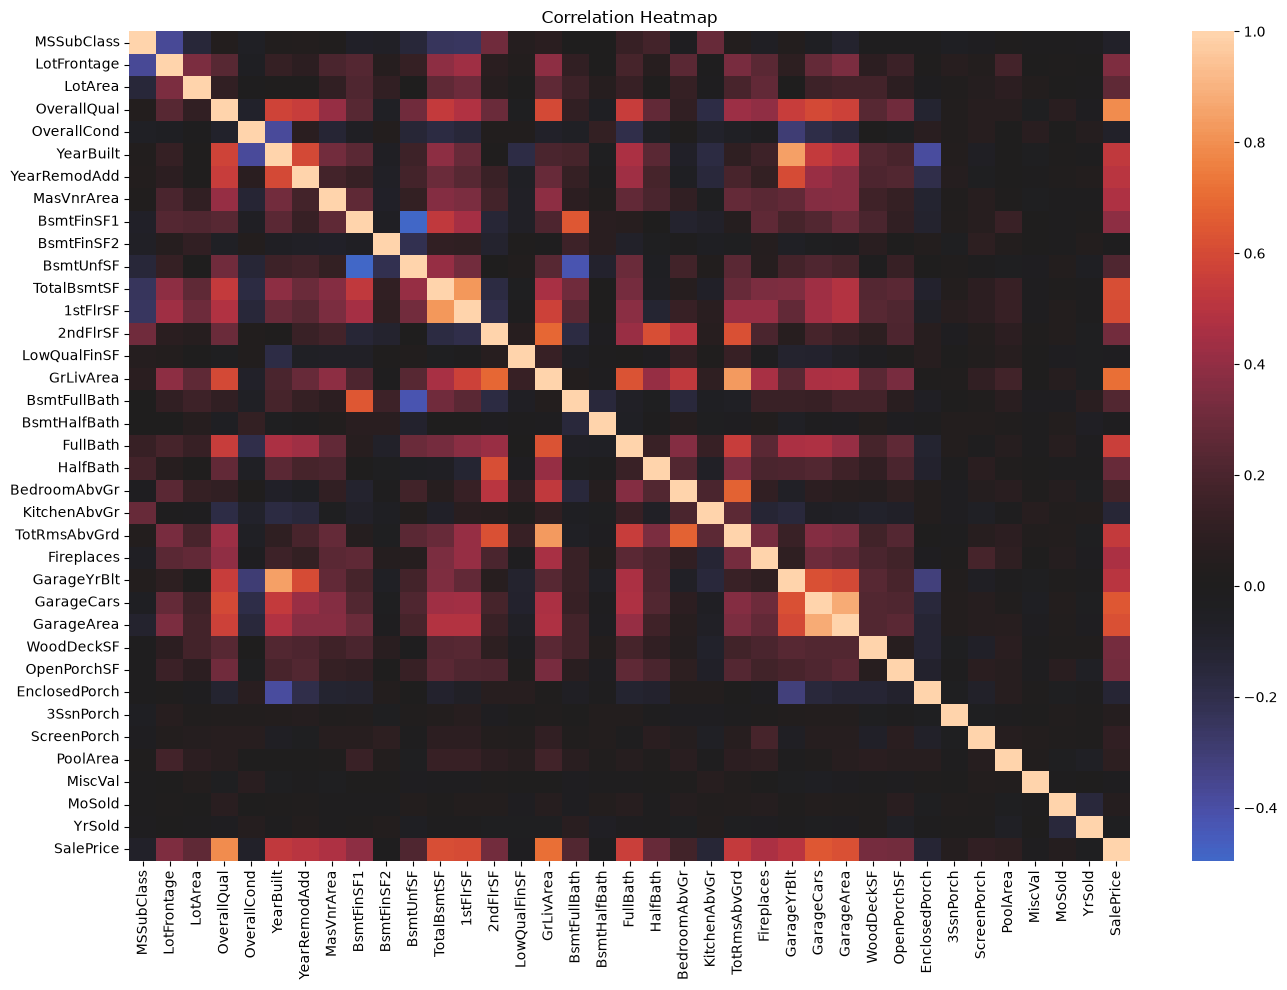

In [17]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    train.select_dtypes(include="number").corr(),
    center=0
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**What we learned**

The heatmap confirms groups of correlated variables such as `GarageCars`/`GarageArea`, `TotalBsmtSF`/`1stFlrSF`, and `GrLivArea`/`TotRmsAbvGrd`.

This does not mean we must delete one member of every pair. We will let model comparison tell us whether a particular model handles the redundancy well.

## 8. Zero-inflation check

In [18]:
zero_pct = (
    (train[numeric_cols] == 0)
    .mean()
    .sort_values(ascending=False) * 100
)

display(zero_pct)

PoolArea         99.520548
3SsnPorch        98.356164
LowQualFinSF     98.219178
MiscVal          96.438356
BsmtHalfBath     94.383562
ScreenPorch      92.054795
BsmtFinSF2       88.561644
EnclosedPorch    85.753425
HalfBath         62.534247
MasVnrArea       59.520548
BsmtFullBath     58.630137
2ndFlrSF         56.780822
WoodDeckSF       52.123288
Fireplaces       47.260274
OpenPorchSF      44.931507
BsmtFinSF1       31.986301
BsmtUnfSF         8.082192
GarageCars        5.547945
GarageArea        5.547945
TotalBsmtSF       2.534247
FullBath          0.616438
BedroomAbvGr      0.410959
KitchenAbvGr      0.068493
OverallCond       0.000000
LotFrontage       0.000000
MSSubClass        0.000000
OverallQual       0.000000
LotArea           0.000000
1stFlrSF          0.000000
GrLivArea         0.000000
YearRemodAdd      0.000000
YearBuilt         0.000000
GarageYrBlt       0.000000
TotRmsAbvGrd      0.000000
MoSold            0.000000
YrSold            0.000000
SalePrice         0.000000
d

**What we learned**

Several numerical features are zero for most houses (`PoolArea`, `3SsnPorch`, `LowQualFinSF`, `MiscVal`, `ScreenPorch`, and others). A zero here often means the feature does not exist.

We do not automatically convert these into new `Has*` flags. Those are optional feature-engineering ideas and are **deferred for now**.

## 9. Numeric transformation — deciding where `log1p` is appropriate

### Decision rule

We will not log-transform every numeric feature.

For each **non-negative continuous candidate**, we test:

1. Is the original absolute skewness greater than `0.75`?
2. Does `log1p` reduce the absolute skewness by at least **30%**?

The rule is:

```python
abs(raw_skew) > 0.75
and
abs(log1p_skew) < abs(raw_skew) * 0.70
```

The `0.75` threshold is a practical screening threshold: below it, the feature is not strongly skewed enough to justify a transformation automatically.

The `30%` improvement requirement prevents us from applying a transformation that barely helps—or makes the distribution worse.

In [19]:
log_candidates = [
    "GrLivArea",
    "LotArea",
    "TotalBsmtSF",
    "MasVnrArea",
    "1stFlrSF",
    "2ndFlrSF",
    "GarageArea",
    "LotFrontage",
    "BsmtFinSF1",
    "BsmtUnfSF",
    "WoodDeckSF",
    "OpenPorchSF"
]

skew_rows = []

for col in log_candidates:
    raw_skew = train[col].skew()
    log_skew = np.log1p(train[col]).skew()

    recommended = (
        (train[col] >= 0).all()
        and abs(raw_skew) > 0.75
        and abs(log_skew) < abs(raw_skew) * 0.70
    )

    skew_rows.append({
        "column": col,
        "raw_skew": raw_skew,
        "log1p_skew": log_skew,
        "recommended": recommended
    })

skew_report = pd.DataFrame(skew_rows)
skew_report

,column,raw_skew,log1p_skew,recommended
0,GrLivArea,1.366560,-0.006140,True
1,LotArea,12.207688,-0.137404,True
2,TotalBsmtSF,1.524255,-5.154670,False
3,MasVnrArea,2.677616,0.503532,True
4,1stFlrSF,1.376757,0.080114,True
5,2ndFlrSF,0.813030,0.289643,True
6,GarageArea,0.179981,-3.482604,False
7,LotFrontage,2.212959,-0.908933,True
8,BsmtFinSF1,1.685503,-0.618410,True
9,BsmtUnfSF,0.920268,-2.186504,False


**What we learned**

The table gives us an evidence-based decision instead of choosing by eye.

A feature is recommended only when it is sufficiently skewed **and** `log1p` clearly improves the skewness.

In particular, `TotalBsmtSF`, `GarageArea`, and `BsmtUnfSF` are not selected because their log-transformed distributions become worse. `GarageArea` also starts with very little skew.

In [20]:
log_transform_cols = skew_report.loc[
    skew_report["recommended"],
    "column"
].tolist()

print("Selected for log1p:")
print(log_transform_cols)

Selected for log1p:
['GrLivArea', 'LotArea', 'MasVnrArea', '1stFlrSF', '2ndFlrSF', 'LotFrontage', 'BsmtFinSF1', 'WoodDeckSF', 'OpenPorchSF']


**Final transformation decision**

The selected features are the ones for which the measured skewness improved enough to justify `log1p`.

We are **not** applying log transformation to:

- binary variables,
- categorical variables,
- year variables such as `YearBuilt`/`YrSold`,
- or numeric variables where the log transformation worsened the distribution.

Standardization will be handled later **only inside models that benefit from scaling**. It is not a universal transformation.

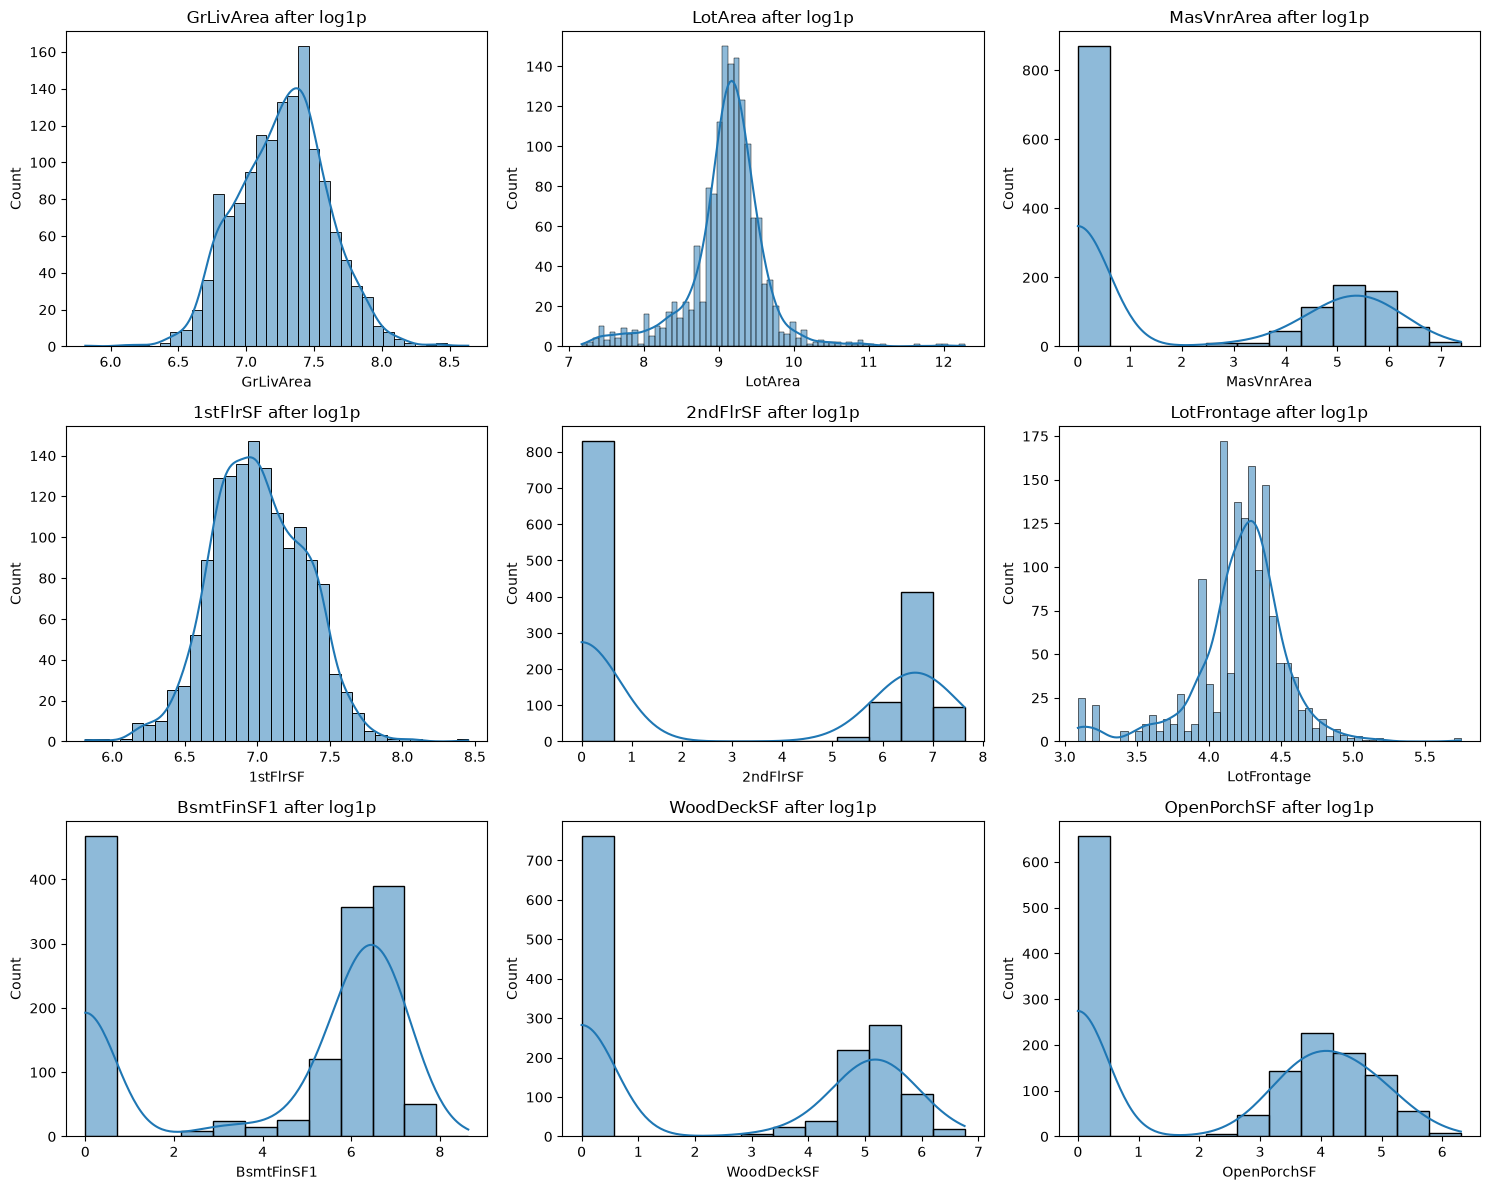

In [21]:
transformed = train.copy()

for col in log_transform_cols:
    transformed[col] = np.log1p(transformed[col])

fig, axes = plt.subplots(
    3, 3,
    figsize=(15, 12)
)

axes = axes.flatten()

for i, col in enumerate(log_transform_cols):
    sns.histplot(
        transformed[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} after log1p")
    axes[i].set_xlabel(col)

for i in range(len(log_transform_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

**What we learned**

The post-transformation plots let us visually verify what the skewness table told us.

The purpose is **not** to force every feature into a perfect normal distribution. The goal is to reduce problematic right-skew and compress extreme values where the transformation actually helps.

## 10. Categorical encoding

### Why these encoding choices?

**Ordinal categorical features** have a real order (for example `Po < Fa < TA < Gd < Ex`). We therefore use explicit ordinal mappings so the numerical values preserve that order.

We do **not** use `LabelEncoder` for these feature columns because its integer labels do not express a guaranteed domain-specific order.

**Binary features** such as `CentralAir` can be represented as `0/1`.

**Nominal categorical features** have no natural order, so we use one-hot encoding with `pd.get_dummies()`.

The actual category values come from the training data—not from manually copying the labels in `data_description.txt`.

In [22]:
ORDINAL_MAPS = {
    "ExterQual": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "ExterCond": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "HeatingQC": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "KitchenQual": {"Po": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "BsmtQual": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtCond": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "FireplaceQu": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageQual": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageCond": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "PoolQC": {"None": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "LotShape": {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3},
    "LandSlope": {"Sev": 0, "Mod": 1, "Gtl": 2},
    "PavedDrive": {"N": 0, "P": 1, "Y": 2},
    "Alley": {"None": 0, "Grvl": 1, "Pave": 2},
    "Functional": {
        "Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3,
        "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7
    },
}

BINARY_MAP = {
    "CentralAir": {"N": 0, "Y": 1}
}


def encode_features(df):
    df = df.copy()

    for col, mapping in ORDINAL_MAPS.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    for col, mapping in BINARY_MAP.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    nominal_cols = df.select_dtypes(
        include=["object", "string"]
    ).columns.tolist()

    df = pd.get_dummies(
        df,
        columns=nominal_cols,
        dummy_na=False,
        dtype=int
    )

    return df

**What we learned**

The encoding function separates the three cases correctly:

- ordered categories → ordinal mapping,
- binary category → `0/1`,
- unordered categories → one-hot columns.

This is **preprocessing**, not feature creation.

## 11. Final modeling dataset

In [23]:
prepared = transformed.copy()
prepared = encode_features(prepared)

print("Prepared shape:", prepared.shape)
print("Missing values:", prepared.isna().sum().sum())
print("Data types remaining:", prepared.dtypes.value_counts())

Prepared shape: (1460, 228)
Missing values: 0
Data types remaining: int64      218
float64     10
Name: count, dtype: int64


**What we learned**

`prepared` is now the single final DataFrame used for model experiments.

It contains:

- cleaned values,
- selected `log1p` feature transformations,
- encoded categorical features,
- the original `SalePrice` target.

We keep `SalePrice` in its original scale here and transform it only when creating `y`, so there is no accidental target leakage.

## 12. Outlier experiment

We identified two suspicious `GrLivArea` rows. We will not delete them yet.

To test their effect fairly:

- the same validation set is used in both runs;
- the two rows are excluded from validation;
- Run A trains with the two rows;
- Run B trains without them.

This means the only intended difference is whether the model saw those two observations during training.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

outlier_ids = train.loc[
    outlier_mask
].index

non_outlier = prepared.drop(index=outlier_ids)
outlier_rows = prepared.loc[outlier_ids]

feature_columns = [
    col for col in prepared.columns
    if col != "SalePrice"
]

train_base, val_base = train_test_split(
    non_outlier,
    test_size=0.20,
    random_state=42
)

X_out_train = train_base[feature_columns]
y_out_train = np.log1p(train_base["SalePrice"])

X_out_val = val_base[feature_columns]
y_out_val = np.log1p(val_base["SalePrice"])

# Run A: keep the two observations in training
train_with = pd.concat([train_base, outlier_rows])

model_with = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_with.fit(
    train_with[feature_columns],
    np.log1p(train_with["SalePrice"])
)

pred_with = model_with.predict(X_out_val)
rmse_with = np.sqrt(mean_squared_error(y_out_val, pred_with))

# Run B: remove them from training
model_without = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_without.fit(
    X_out_train,
    y_out_train
)

pred_without = model_without.predict(X_out_val)
rmse_without = np.sqrt(mean_squared_error(y_out_val, pred_without))

print(f"With outliers:    {rmse_with:.5f}")
print(f"Without outliers: {rmse_without:.5f}")

With outliers:    0.14245
Without outliers: 0.14263


**Decision**

The previous fixed-split experiment gave approximately:

- With the two rows: **0.14237**
- Without the two rows: **0.14258**

Lower is better, so this experiment slightly favors **keeping** the two rows.

Because the difference is very small and comes from one validation split, we keep them for now rather than claiming they are universally harmful.

## 13. Final train / validation split

In [25]:
X = prepared.drop(columns="SalePrice")
y = np.log1p(prepared["SalePrice"])

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Validation rows:", len(X_val))

Training shape: (1168, 227)
Validation shape: (292, 227)
Validation rows: 292


**What we learned**

We now have one final training/validation split for model comparison.

The Kaggle `test.csv` is still untouched. It will only be used after the model and preprocessing decisions are finalized.

## 14. Regression evaluation and diagnostics

Confusion matrices, accuracy, precision, recall, F1, and ROC-AUC are **classification metrics** and do not apply to this continuous `SalePrice` target.

For this regression problem we use:

- **log-RMSE** → the main Kaggle metric;
- **RMSE in dollars** → easier to interpret in price units;
- **R²** → additional explanatory metric;
- **Train/validation gap** → helps us notice overfitting.

Each model cell below will also show three diagnostics:

1. Actual vs Predicted.
2. Residuals vs Predicted.
3. Residual distribution.

In [26]:
def evaluate_model(model, model_name):
    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Main competition metric
    train_log_rmse = np.sqrt(
        mean_squared_error(y_train, y_train_pred)
    )
    val_log_rmse = np.sqrt(
        mean_squared_error(y_val, y_val_pred)
    )

    # Original price scale
    train_rmse = np.sqrt(
        mean_squared_error(
            np.expm1(y_train),
            np.expm1(y_train_pred)
        )
    )
    val_rmse = np.sqrt(
        mean_squared_error(
            np.expm1(y_val),
            np.expm1(y_val_pred)
        )
    )

    # Additional metrics
    val_mae = mean_absolute_error(
        np.expm1(y_val),
        np.expm1(y_val_pred)
    )

    val_r2 = r2_score(y_val, y_val_pred)

    residuals = y_val - y_val_pred

    result = {
        "Model": model_name,
        "Train log-RMSE": train_log_rmse,
        "Validation log-RMSE": val_log_rmse,
        "Train RMSE": train_rmse,
        "Validation RMSE": val_rmse,
        "Validation MAE": val_mae,
        "Validation R2": val_r2,
        "Train/Val Gap": val_log_rmse - train_log_rmse,
    }

    print(f"{model_name}")
    print("=" * 50)
    print(f"Train log-RMSE:      {train_log_rmse:.5f}")
    print(f"Validation log-RMSE: {val_log_rmse:.5f}")
    print(f"Train RMSE:          ${train_rmse:,.0f}")
    print(f"Validation RMSE:     ${val_rmse:,.0f}")
    print(f"Validation MAE:      ${val_mae:,.0f}")
    print(f"Validation R²:       {val_r2:.4f}")
    print(f"Train/Val Gap:       {val_log_rmse - train_log_rmse:.5f}")

    # Three diagnostics + metrics panel
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # 1. Actual vs Predicted
    axes[0].scatter(
        np.expm1(y_val),
        np.expm1(y_val_pred),
        alpha=0.6
    )

    min_value = min(
        np.expm1(y_val).min(),
        np.expm1(y_val_pred).min()
    )
    max_value = max(
        np.expm1(y_val).max(),
        np.expm1(y_val_pred).max()
    )

    axes[0].plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    axes[0].set_title("Actual vs Predicted")
    axes[0].set_xlabel("Actual SalePrice")
    axes[0].set_ylabel("Predicted SalePrice")

    # 2. Residuals vs Predicted
    axes[1].scatter(
        y_val_pred,
        residuals,
        alpha=0.6
    )
    axes[1].axhline(0, linestyle="--")
    axes[1].set_title("Residuals vs Predicted")
    axes[1].set_xlabel("Predicted log(SalePrice)")
    axes[1].set_ylabel("Residual")

    # 3. Residual distribution
    sns.histplot(
        residuals,
        kde=True,
        ax=axes[2]
    )
    axes[2].set_title("Residual Distribution")
    axes[2].set_xlabel("Residual")
    axes[2].set_ylabel("Count")

    # 4. Metrics
    axes[3].axis("off")
    axes[3].text(
        0.05,
        0.95,
        (
            f"{model_name}\n\n"
            f"Val log-RMSE: {val_log_rmse:.5f}\n\n"
            f"Val RMSE: ${val_rmse:,.0f}\n\n"
            f"Val MAE: ${val_mae:,.0f}\n\n"
            f"R²: {val_r2:.4f}\n\n"
            f"Gap: {val_log_rmse - train_log_rmse:.5f}"
        ),
        va="top",
        fontsize=11
    )

    fig.suptitle(model_name, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return result

## 15. Model comparison

We compare a representative set of regression families.

**Models that use scaling inside a pipeline:** Linear Regression, Ridge, Lasso, Elastic Net, and SVR.

**Models that do not need scaling:** Decision Tree, Random Forest, Extra Trees, Gradient Boosting, and HistGradientBoosting.

Scaling is therefore **model-specific**, not a universal preprocessing step.

In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### 15.1. Linear Regression

Linear Regression
Train log-RMSE:      0.09304
Validation log-RMSE: 0.12259
Train RMSE:          $18,185
Validation RMSE:     $22,816
Validation MAE:      $14,718
Validation R²:       0.9195
Train/Val Gap:       0.02955


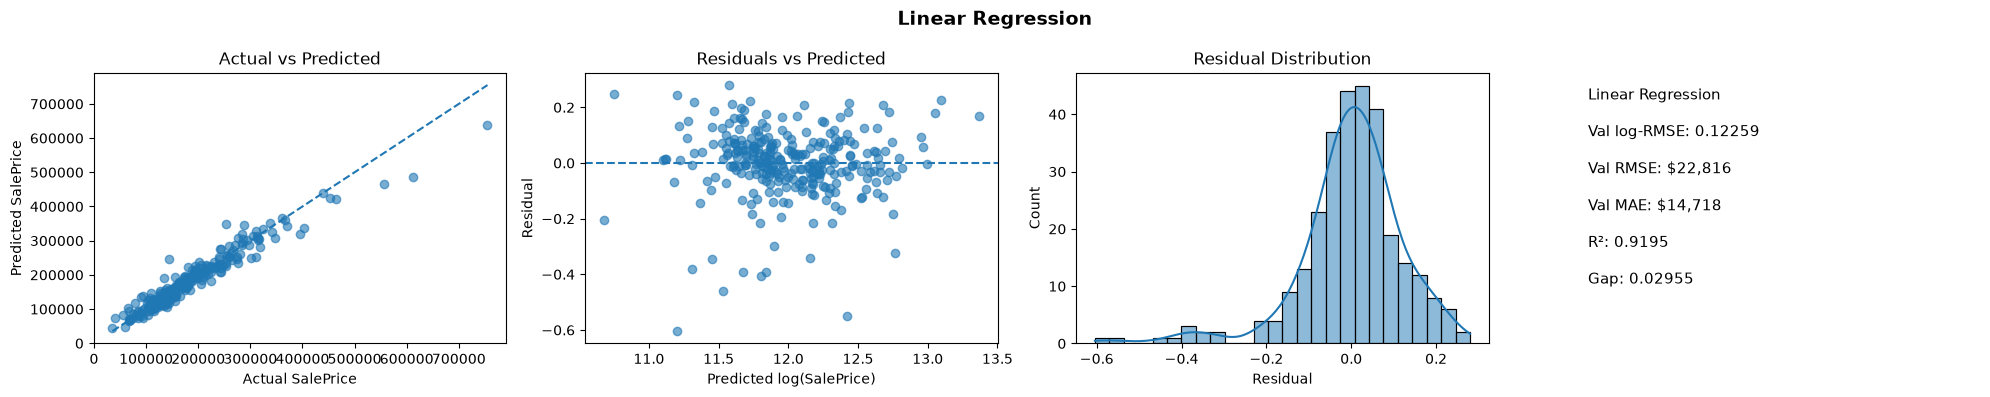

In [28]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_result = evaluate_model(
    linear_model,
    "Linear Regression"
)

**What to look for**

The cell reports this model's training and validation metrics and shows its three diagnostics. For this project, the primary comparison value is **Validation log-RMSE: lower is better**.

Also inspect the train/validation gap and the residual plots. A lower validation score is useful only if the model is not clearly overfitting.

### 15.2. Ridge Regression

Ridge Regression
Train log-RMSE:      0.09320
Validation log-RMSE: 0.12132
Train RMSE:          $18,240
Validation RMSE:     $22,683
Validation MAE:      $14,584
Validation R²:       0.9211
Train/Val Gap:       0.02812


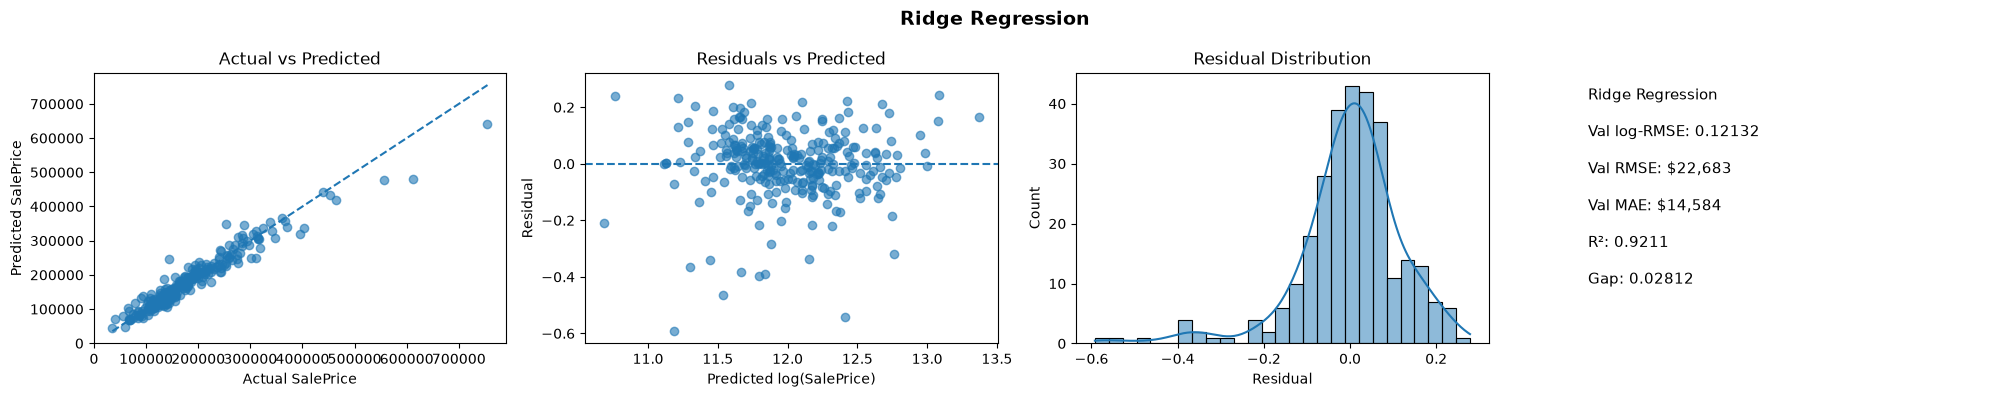

In [29]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0))
])

ridge_result = evaluate_model(
    ridge_model,
    "Ridge Regression"
)

**What to look for**

The cell reports this model's training and validation metrics and shows its three diagnostics. For this project, the primary comparison value is **Validation log-RMSE: lower is better**.

Also inspect the train/validation gap and the residual plots. A lower validation score is useful only if the model is not clearly overfitting.

### 15.3. Lasso Regression

Lasso Regression
Train log-RMSE:      0.09363
Validation log-RMSE: 0.12078
Train RMSE:          $18,464
Validation RMSE:     $22,765
Validation MAE:      $14,378
Validation R²:       0.9218
Train/Val Gap:       0.02716


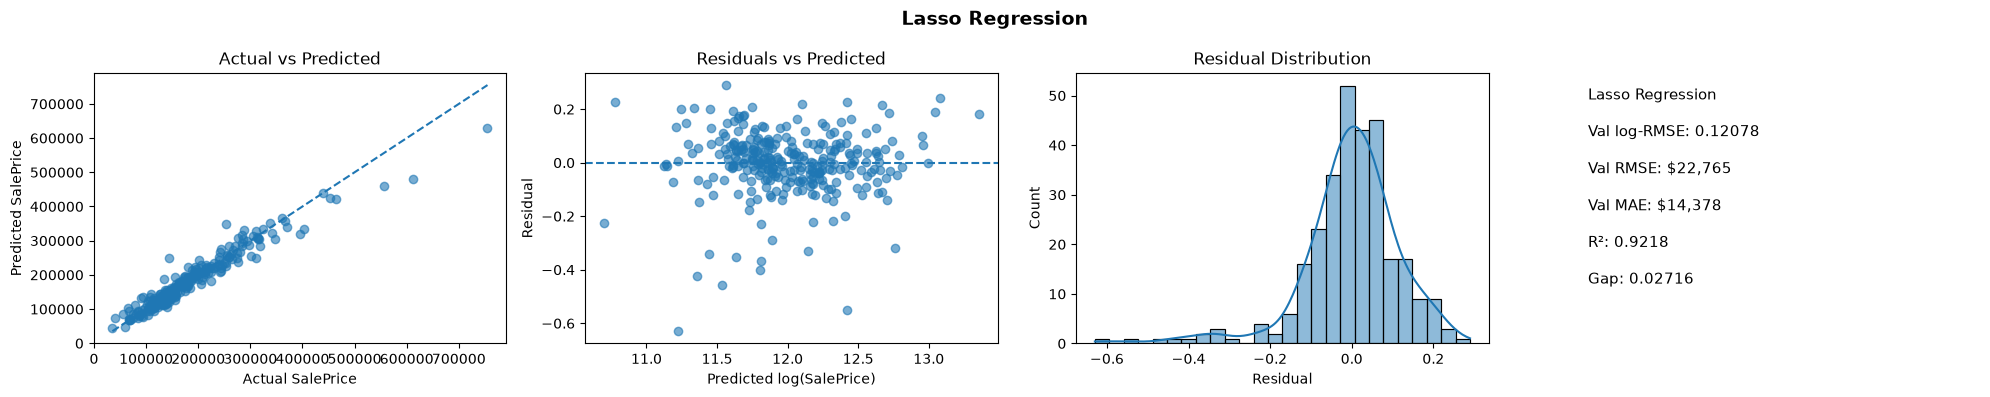

In [30]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.0005, max_iter=10000))
])

lasso_result = evaluate_model(
    lasso_model,
    "Lasso Regression"
)

**What to look for**

The cell reports this model's training and validation metrics and shows its three diagnostics. For this project, the primary comparison value is **Validation log-RMSE: lower is better**.

Also inspect the train/validation gap and the residual plots. A lower validation score is useful only if the model is not clearly overfitting.

### 15.4. Elastic Net

Elastic Net
Train log-RMSE:      0.09327
Validation log-RMSE: 0.12116
Train RMSE:          $18,298
Validation RMSE:     $22,721
Validation MAE:      $14,447
Validation R²:       0.9213
Train/Val Gap:       0.02790


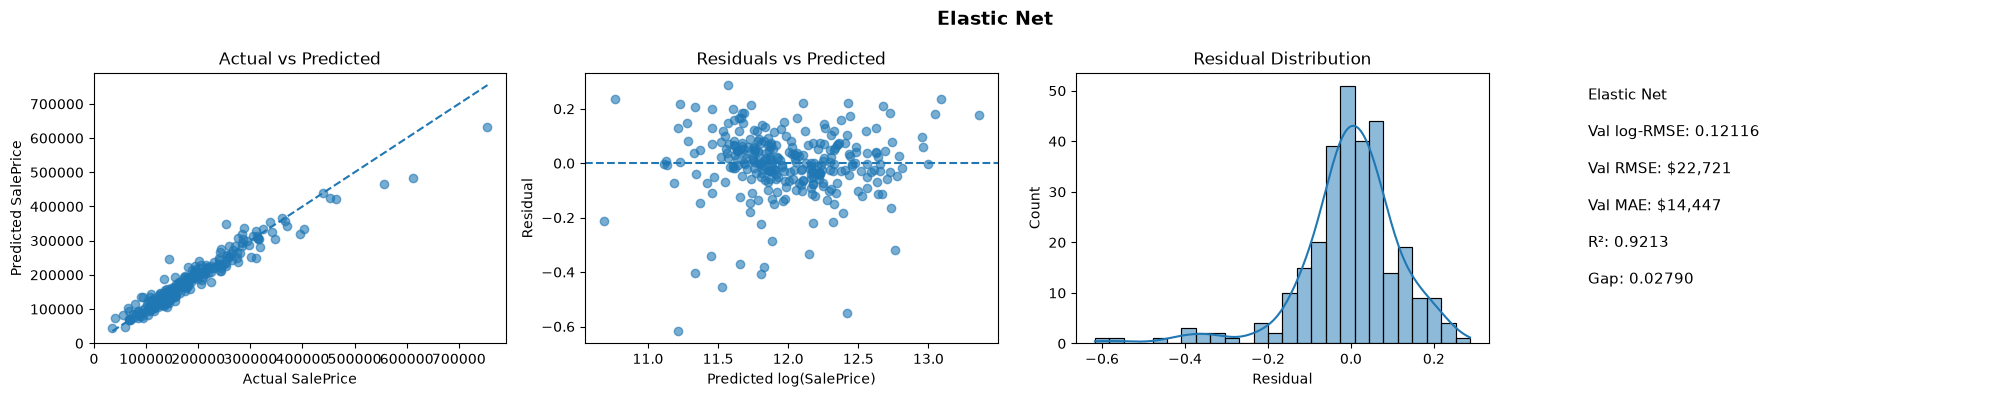

In [31]:
elastic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=0.0005,
        l1_ratio=0.5,
        max_iter=10000
    ))
])

elastic_result = evaluate_model(
    elastic_model,
    "Elastic Net"
)

**What to look for**

The cell reports this model's training and validation metrics and shows its three diagnostics. For this project, the primary comparison value is **Validation log-RMSE: lower is better**.

Also inspect the train/validation gap and the residual plots. A lower validation score is useful only if the model is not clearly overfitting.

### 15.5. Decision Tree

Decision Tree
Train log-RMSE:      0.00000
Validation log-RMSE: 0.18385
Train RMSE:          $0
Validation RMSE:     $33,153
Validation MAE:      $23,222
Validation R²:       0.8189
Train/Val Gap:       0.18385


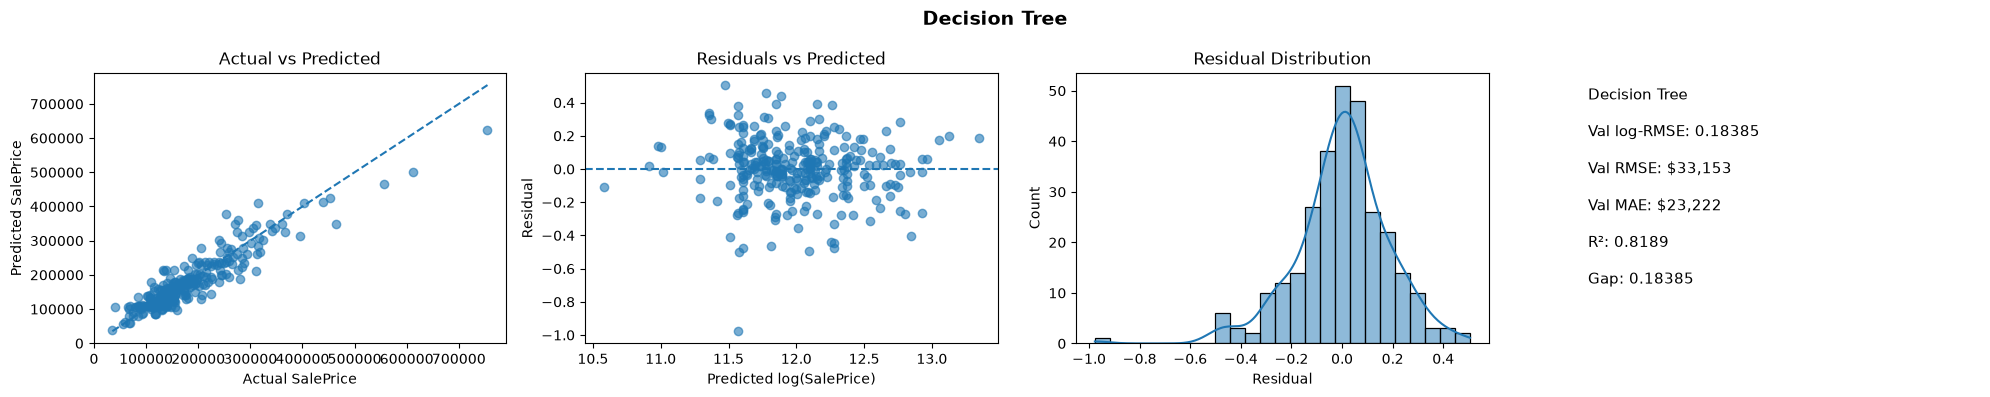

In [32]:
tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_result = evaluate_model(
    tree_model,
    "Decision Tree"
)

**What to look for**

The cell reports this model's training and validation metrics and shows its three diagnostics. For this project, the primary comparison value is **Validation log-RMSE: lower is better**.

Also inspect the train/validation gap and the residual plots. A lower validation score is useful only if the model is not clearly overfitting.

### 15.6. Random Forest

Random Forest
Train log-RMSE:      0.05342
Validation log-RMSE: 0.14495
Train RMSE:          $11,255
Validation RMSE:     $29,163
Validation MAE:      $17,374
Validation R²:       0.8874
Train/Val Gap:       0.09153


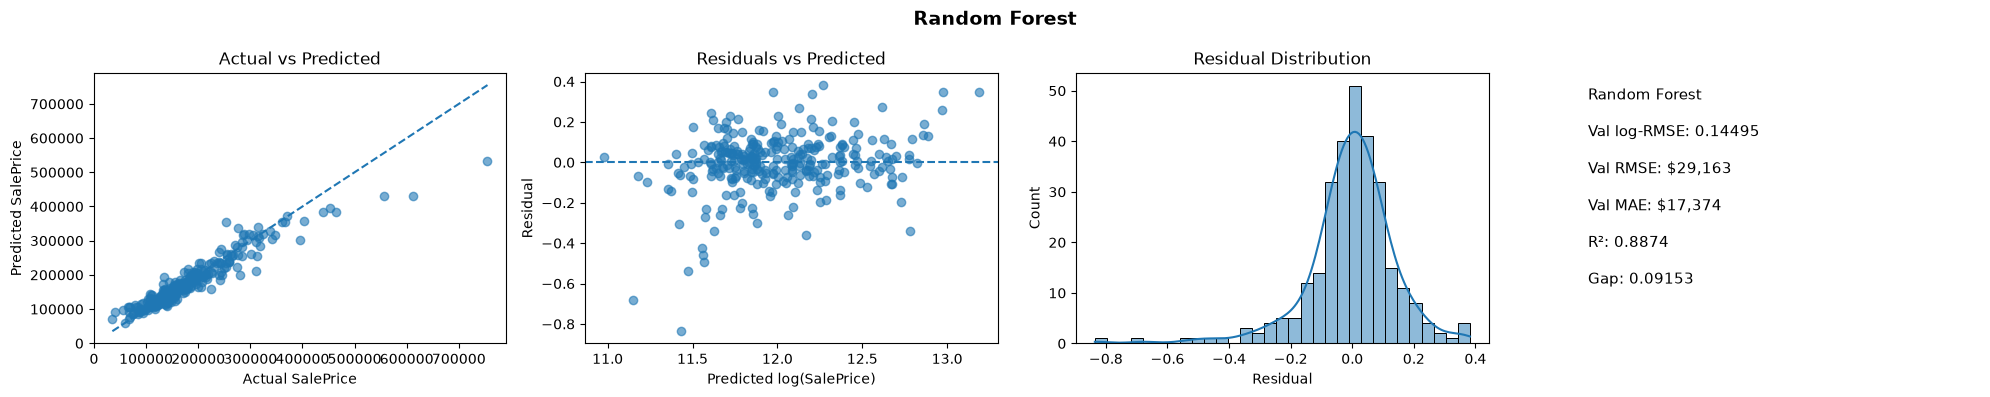

In [33]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_result = evaluate_model(
    rf_model,
    "Random Forest"
)

**What to look for**

The cell reports this model's training and validation metrics and shows its three diagnostics. For this project, the primary comparison value is **Validation log-RMSE: lower is better**.

Also inspect the train/validation gap and the residual plots. A lower validation score is useful only if the model is not clearly overfitting.

### 15.7. Extra Trees

Extra Trees
Train log-RMSE:      0.00000
Validation log-RMSE: 0.14301
Train RMSE:          $0
Validation RMSE:     $28,331
Validation MAE:      $17,041
Validation R²:       0.8904
Train/Val Gap:       0.14301


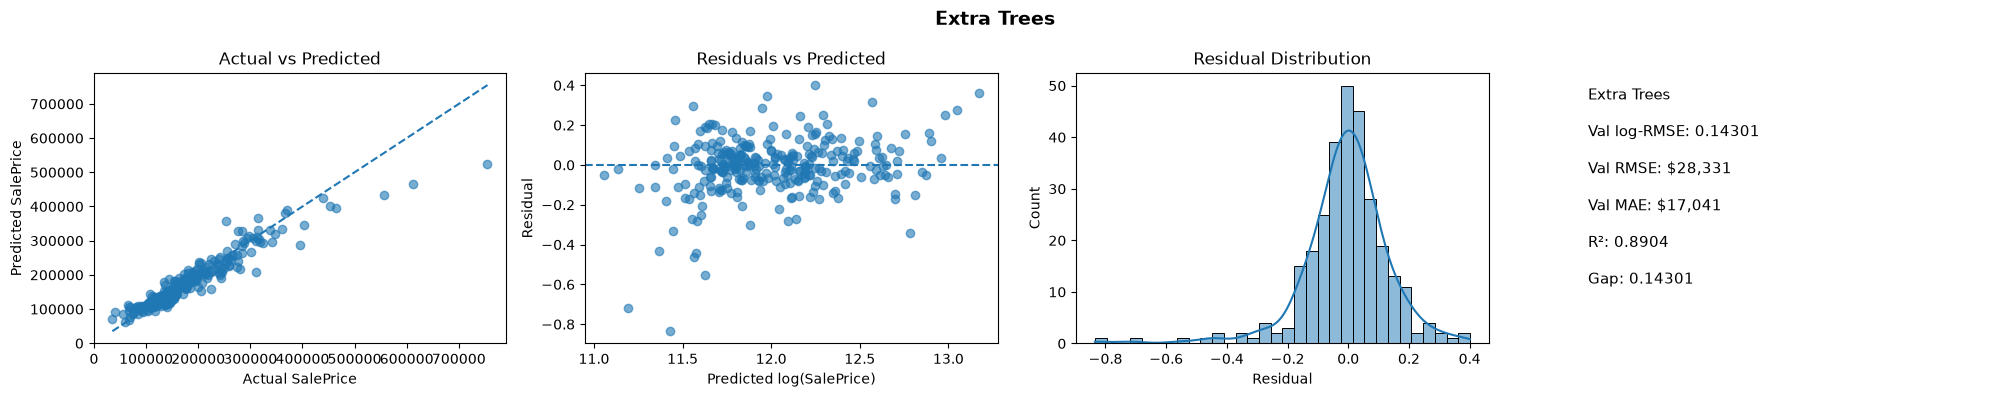

In [34]:
extra_model = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

extra_result = evaluate_model(
    extra_model,
    "Extra Trees"
)

**What to look for**

The cell reports this model's training and validation metrics and shows its three diagnostics. For this project, the primary comparison value is **Validation log-RMSE: lower is better**.

Also inspect the train/validation gap and the residual plots. A lower validation score is useful only if the model is not clearly overfitting.

### 15.8. Gradient Boosting

Gradient Boosting
Train log-RMSE:      0.07577
Validation log-RMSE: 0.13764
Train RMSE:          $14,197
Validation RMSE:     $30,119
Validation MAE:      $16,586
Validation R²:       0.8985
Train/Val Gap:       0.06187


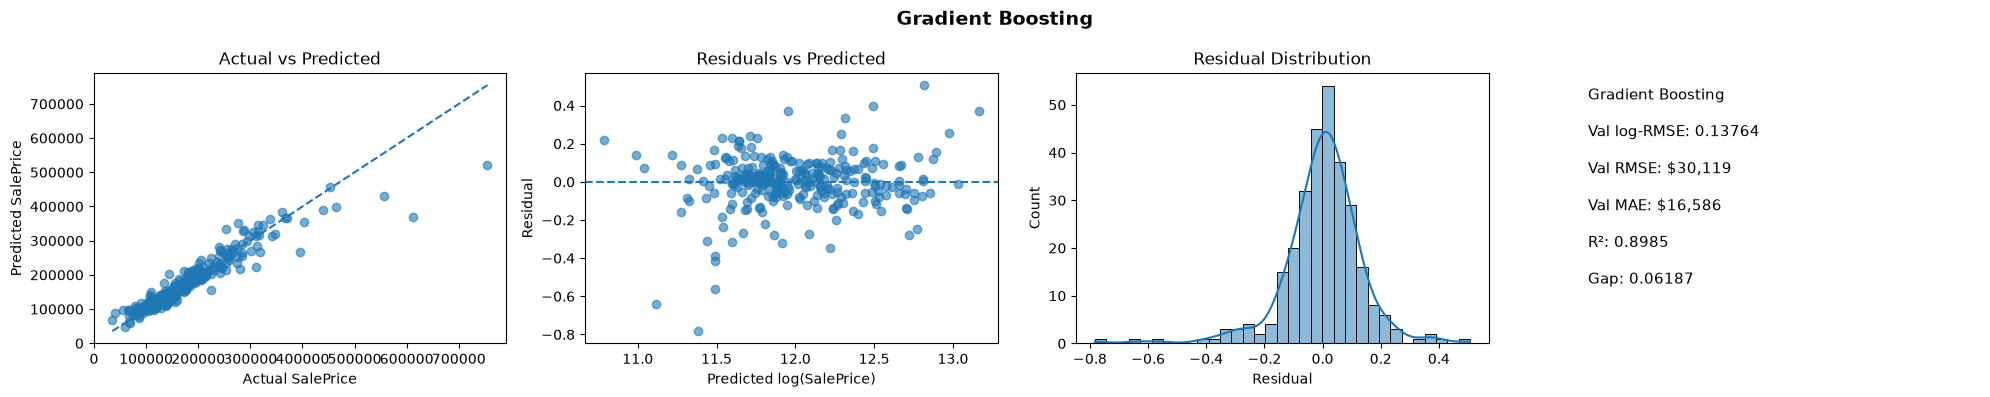

In [35]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_result = evaluate_model(
    gb_model,
    "Gradient Boosting"
)

**What to look for**

The cell reports this model's training and validation metrics and shows its three diagnostics. For this project, the primary comparison value is **Validation log-RMSE: lower is better**.

Also inspect the train/validation gap and the residual plots. A lower validation score is useful only if the model is not clearly overfitting.

### 15.9. Hist Gradient Boosting

Hist Gradient Boosting
Train log-RMSE:      0.04162
Validation log-RMSE: 0.13793
Train RMSE:          $9,527
Validation RMSE:     $29,518
Validation MAE:      $16,528
Validation R²:       0.8981
Train/Val Gap:       0.09631


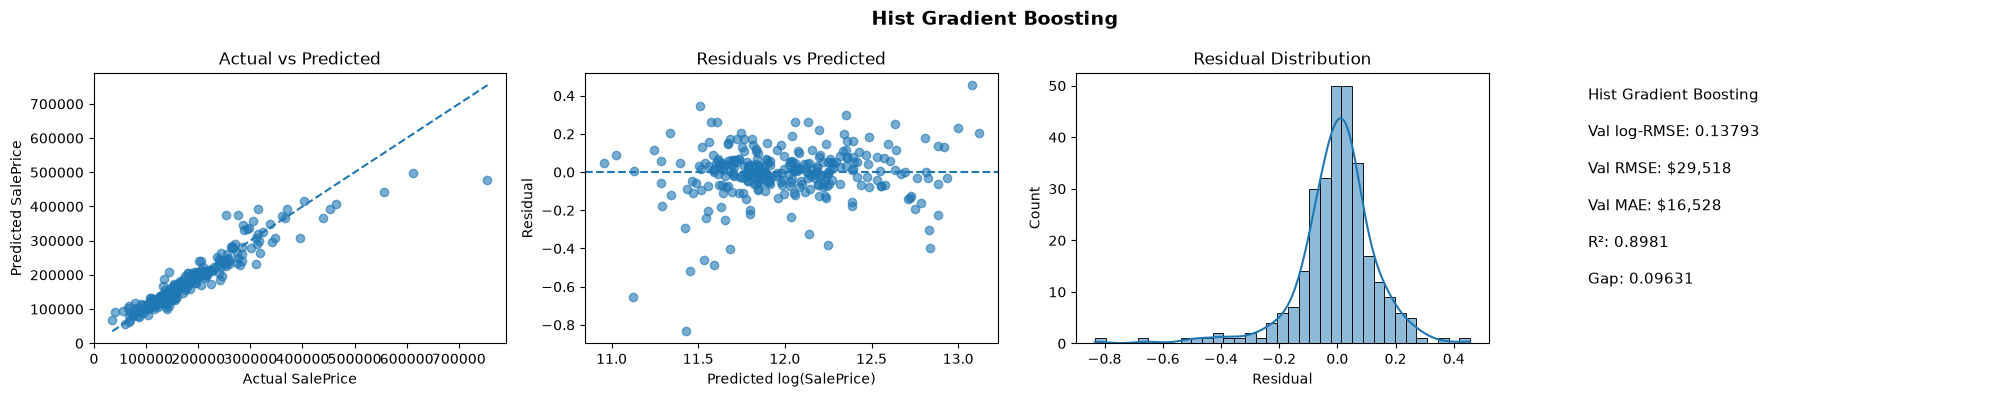

In [36]:
hist_model = HistGradientBoostingRegressor(
    random_state=42
)

hist_result = evaluate_model(
    hist_model,
    "Hist Gradient Boosting"
)

**What to look for**

The cell reports this model's training and validation metrics and shows its three diagnostics. For this project, the primary comparison value is **Validation log-RMSE: lower is better**.

Also inspect the train/validation gap and the residual plots. A lower validation score is useful only if the model is not clearly overfitting.

### 15.10. Support Vector Regression

Support Vector Regression
Train log-RMSE:      0.07817
Validation log-RMSE: 0.21650
Train RMSE:          $17,078
Validation RMSE:     $45,123
Validation MAE:      $21,961
Validation R²:       0.7488
Train/Val Gap:       0.13833


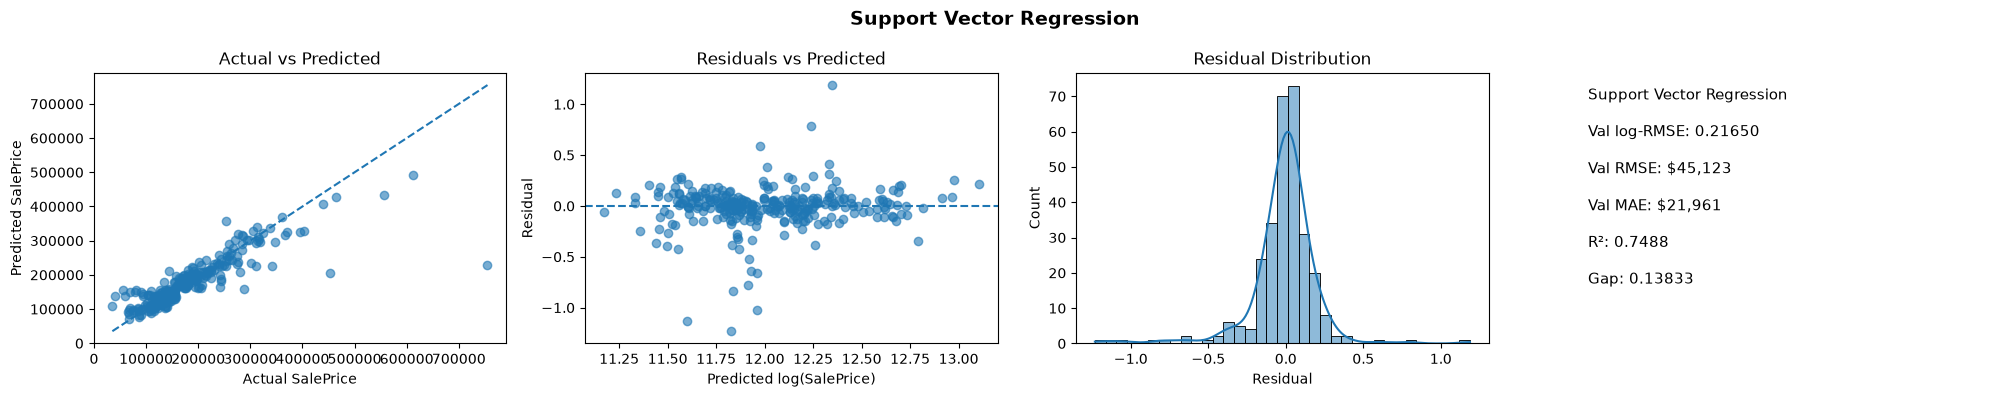

In [37]:
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf"))
])

svr_result = evaluate_model(
    svr_model,
    "Support Vector Regression"
)

**What to look for**

The cell reports this model's training and validation metrics and shows its three diagnostics. For this project, the primary comparison value is **Validation log-RMSE: lower is better**.

Also inspect the train/validation gap and the residual plots. A lower validation score is useful only if the model is not clearly overfitting.

## 16. Final model comparison table

In [38]:
all_results = [
    linear_result,
    ridge_result,
    lasso_result,
    elastic_result,
    tree_result,
    rf_result,
    extra_result,
    gb_result,
    hist_result,
    svr_result,
]

results_df = (
    pd.DataFrame(all_results)
    .sort_values("Validation log-RMSE")
    .reset_index(drop=True)
)

display(
    results_df.style.format({
        "Train log-RMSE": "{:.5f}",
        "Validation log-RMSE": "{:.5f}",
        "Train RMSE": "${:,.0f}",
        "Validation RMSE": "${:,.0f}",
        "Validation MAE": "${:,.0f}",
        "Validation R2": "{:.4f}",
        "Train/Val Gap": "{:.5f}",
    })
)

,Model,Train log-RMSE,Validation log-RMSE,Train RMSE,Validation RMSE,Validation MAE,Validation R2,Train/Val Gap
0,Lasso Regression,0.09363,0.12078,"$18,464","$22,765","$14,378",0.9218,0.02716
1,Elastic Net,0.09327,0.12116,"$18,298","$22,721","$14,447",0.9213,0.02790
2,Ridge Regression,0.09320,0.12132,"$18,240","$22,683","$14,584",0.9211,0.02812
3,Linear Regression,0.09304,0.12259,"$18,185","$22,816","$14,718",0.9195,0.02955
4,Gradient Boosting,0.07577,0.13764,"$14,197","$30,119","$16,586",0.8985,0.06187
5,Hist Gradient Boosting,0.04162,0.13793,"$9,527","$29,518","$16,528",0.8981,0.09631
6,Extra Trees,0.00000,0.14301,$0,"$28,331","$17,041",0.8904,0.14301
7,Random Forest,0.05342,0.14495,"$11,255","$29,163","$17,374",0.8874,0.09153
8,Decision Tree,0.00000,0.18385,$0,"$33,153","$23,222",0.8189,0.18385
9,Support Vector Regression,0.07817,0.21650,"$17,078","$45,123","$21,961",0.7488,0.13833


**What we learned**

This table is the final model-selection view.

- **Validation log-RMSE** is the primary criterion because it matches the Kaggle evaluation objective.
- Train/validation gap helps identify models that memorize the training data.
- RMSE and MAE provide price-scale interpretation.
- R² is supplementary and is not the competition metric.

The best model is the one that gives the strongest validation performance with a reasonable generalization gap—not simply the model with the lowest training error.

## 17. Select the current best model

In [39]:
best_model_name = results_df.loc[0, "Model"]

print("Current best validation model:", best_model_name)
print(
    "Validation log-RMSE:",
    f"{results_df.loc[0, 'Validation log-RMSE']:.5f}"
)

Current best validation model: Lasso Regression
Validation log-RMSE: 0.12078


**Important**

This is the **best model on our current validation split**, not necessarily the final production model.

The next modeling stage can tune this candidate and, if needed, compare it with additional algorithms. For now, the notebook has completed the preprocessing and first-pass model selection stage.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from src.train import get_models

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in get_models().items():
    scores = cross_val_score(
        model, X, y, cv=kf, scoring="neg_root_mean_squared_error"
    )
    cv_results.append({
        "Model": name,
        "CV log-RMSE (mean)": -scores.mean(),
        "CV log-RMSE (std)": scores.std(),
    })

cv_df = pd.DataFrame(cv_results).sort_values("CV log-RMSE (mean)").reset_index(drop=True)
cv_df

## 18. Final notebook summary

### Completed

- Missing values investigated and handled.
- `Id` removed.
- Duplicate check completed.
- Category spelling/value mismatches documented without changing raw column names.
- `Utilities` kept.
- Right-skewed numeric features identified.
- `log1p` applied only where the measured skewness improved enough.
- Log transformation rejected where it made skewness worse.
- Year variables kept as year features.
- Ordinal, binary, and nominal encoding strategy defined.
- Two `GrLivArea` outliers tested rather than automatically deleted.
- Final train/validation split created.
- Multiple regression families compared using the same validation split.
- Each model inspected with metrics and residual diagnostics.

### Deferred intentionally

- Additional feature engineering such as `Has*` flags.
- Rare-category grouping for `Neighborhood`.
- Cross-validation and hyperparameter tuning.
- Additional boosting libraries/models.

### Next stage

Once this notebook is reviewed and accepted, the stable preprocessing and modeling decisions can be extracted into `src/` and covered by tests.

**The notebook is the experimentation record. `src/` will become the reusable implementation.**